# **Revenue Manager's Analysis**

## Objectives

* Answer any unresolved queries coming from the [data collection](/jupyter_notebooks/01_data_collection.ipynb) and [EDA](/jupyter_notebooks/02_cancellation_eda.ipynb) notebooks from the "clients" perspective as though collaborative discussion had occurred.

## Inputs

* outputs/datasets/collection/HotelBookings.csv

## Additional Comments

* This is a supplementary notebook drawing on professional experience to inform cleaning & engineering decisions
* I read the notes on the dataset available on [sciencedirect.com](https://www.sciencedirect.com/science/article/pii/S2352340918315191?via%3Dihub) to learn more about the data provenance and quality.
* Deposit types are described as being categorical, calculated based on the value of the payments identified for the booking in the transaction table *prior* to the bookings arrival or cancellation date. Fully pre-paid bookings are classified as Non Refund, unpaid bookings are No Deposit and partial payments are classified Refundable. 
* It is not clarified whether the transaction table was ever updated on or after the cancellation date so for the purposes of this project, the working assumption is that Non Refund bookings are paid in full.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect'

## Load Dataframe

In [3]:
import pandas as pd

df = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02
3,Resort Hotel,0,13,2023,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02
4,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2023-07-03


---

## Questions awaiting clarification

Q1. Are the duplicate bookings true accidental duplicates, group bookings or coincidental duplicates? <br>
Q2. Can you clarify the nature of the extreme ouliers: bookings with no adults, max values of 10 for children and babies, 8 car parking spaces and the min and max values for ADR?<br>
Q3. Assess missing data in the company, agent and country variables. 

---

## 1. Duplicate Bookings

**1.1 Create duplicates dataframe**

In [4]:
duplicate_df = df[df.duplicated(keep=False)]
duplicate_df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2023-07-03
5,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2023-07-03
21,Resort Hotel,0,72,2023,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2023-07-07
22,Resort Hotel,0,72,2023,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2023-07-07
39,Resort Hotel,0,70,2023,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2023-07-07
43,Resort Hotel,0,70,2023,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2023-07-07
132,Resort Hotel,1,5,2023,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2023-07-01
138,Resort Hotel,1,5,2023,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2023-07-01
198,Resort Hotel,0,0,2023,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2023-07-08
200,Resort Hotel,0,0,2023,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2023-07-08


**1.2 Test for group bookings**

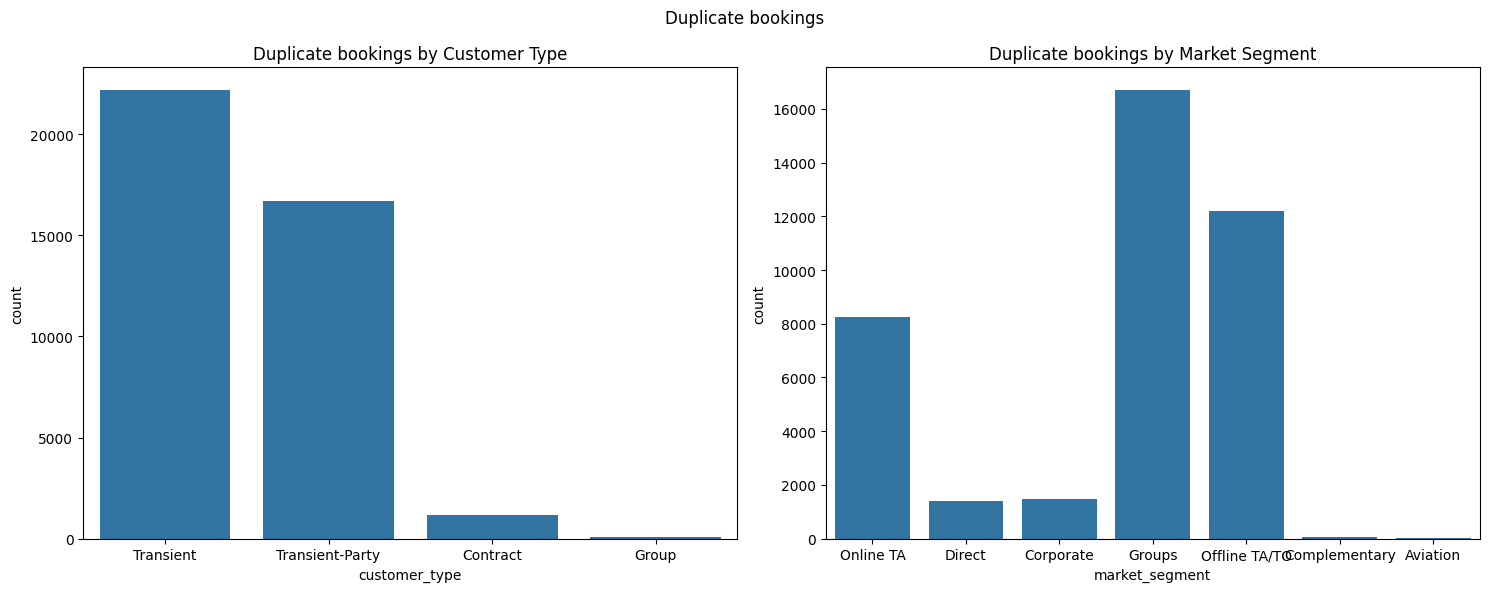

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Duplicate bookings")
ax1.set_title("Duplicate bookings by Customer Type")
ax2.set_title("Duplicate bookings by Market Segment")

sns.countplot(data=duplicate_df,
              x="customer_type",
              ax=ax1)

sns.countplot(data=duplicate_df,
              x="market_segment",
              ax=ax2)

plt.tight_layout()
plt.show()

<Axes: xlabel='customer_type', ylabel='market_segment'>

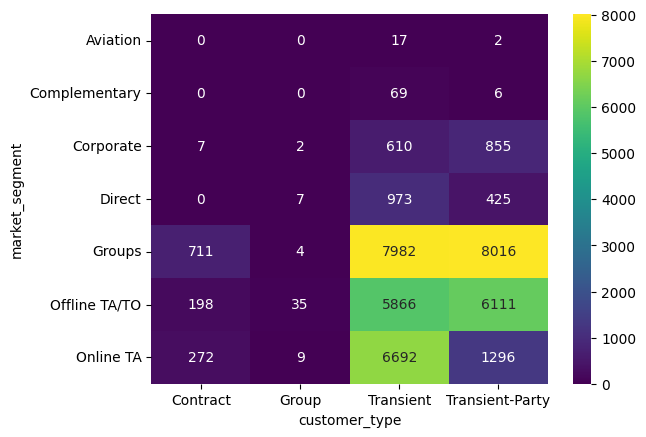

In [6]:
bkg_type = pd.crosstab(duplicate_df["market_segment"], duplicate_df["customer_type"])
sns.heatmap(bkg_type, annot=True, fmt="d", cmap="viridis")

In [7]:
all_groups = (
    (duplicate_df["customer_type"].isin(["Group", "Transient-Party"])) | 
    (duplicate_df["market_segment"] == "Groups")
)

proportion = all_groups.mean()
count = all_groups.sum()

proportion, count

(np.float64(0.6339101207518985), np.int64(25461))

In [22]:
criteria = pd.DataFrame({
    "ct_group": duplicate_df["customer_type"].isin(["Group", "Transient-Party"]),
    "ms_group": duplicate_df["market_segment"] == "Groups"
})

criteria["overlap"] = criteria.sum(axis=1)
criteria["overlap"].value_counts().sort_index()

overlap
0    14704
1    17441
2     8020
Name: count, dtype: int64

* The majority (63%) of duplicated rows are associated with the "Groups" market_segment or "Transient-Party" customer_type, both of which generate genuine repeated bookings (multiple rooms booked together for a family, party, or group). This provides a credible explanation for the bulk of the duplicate set.
* *The possibility of hotel staff user error cannot be completely ruled out for individual cases. However, this type of error is expected to persist in live hotel data, so any predictive model should be built to tolerate it rather than assume a fully deduplicated feed.*

**1.3 Assess index deltas of duplicates to look for large clusters that might suggest database batch export errors**

In [23]:
cols = duplicate_df.columns.to_list()

deltas = (duplicate_df
          .groupby(cols, dropna=False)
          .apply(lambda x: pd.Series(x.index).diff().dropna(), include_groups=False)
          .reset_index(drop=True)
          .rename("index_delta"))

deltas.head(10)

0       30.0
1       17.0
2        1.0
3        1.0
4        6.0
5        3.0
6    35776.0
7        2.0
8    35499.0
9        4.0
Name: index_delta, dtype: float64

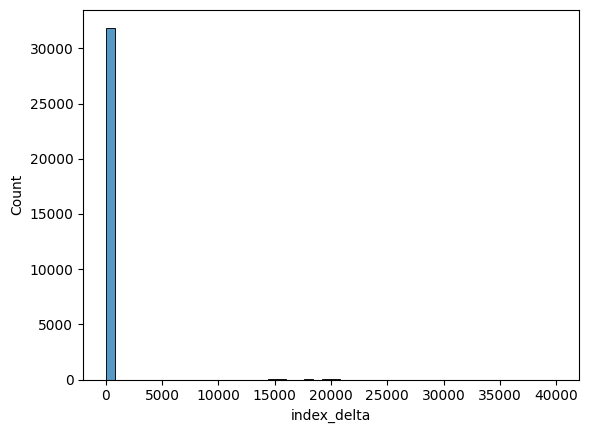

In [24]:
chart = sns.histplot(deltas, bins=50)
plt.show(chart)

* This does show that the duplicates are clustered but the bins are far too wide to be meaningful.

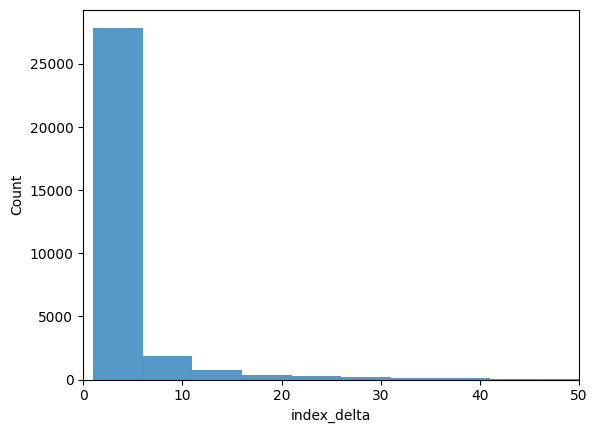

In [25]:
chart = sns.histplot(deltas, bins=8000)
chart.set_xlim(0, 50)
plt.show(chart)

In [26]:
deltas_df = pd.DataFrame({
    "bucket": ["1-2", "3-5", "6-10", "11-20", "21-50", "51-100", "100+"],
    "count": [
        (deltas <= 2).sum(),
        ((deltas > 2) & (deltas <= 5)).sum(),
        ((deltas > 5) & (deltas <= 10)).sum(),
        ((deltas > 10) & (deltas <= 20)).sum(),
        ((deltas > 20) & (deltas <= 50)).sum(),
        ((deltas > 51) & (deltas <= 100)).sum(),
        (deltas > 100).sum(),
    ]
})

deltas_df

,bucket,count
0,1-2,22902
1,3-5,4269
2,6-10,2291
3,11-20,1328
4,21-50,863
5,51-100,188
6,100+,143


* This doesn't really give me the conclusive information required. Large clusters will all have small index deltas.

**1.4 Assess cluster size**

In [ ]:
duplicates = (duplicate_df
            .groupby(cols, dropna=False)
            .size()
            .reset_index(name="duplicate_count"))

duplicates

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,duplicate_count
0,City Hotel,0,0,2023,August,32,7,0,2,2,...,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2023-08-09,2
1,City Hotel,0,0,2023,August,32,8,0,1,2,...,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2023-08-09,2
2,City Hotel,0,0,2023,August,33,10,1,0,2,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-08-11,3
3,City Hotel,0,0,2023,August,33,11,0,1,1,...,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2023-08-12,2
4,City Hotel,0,0,2023,August,33,11,0,1,2,...,NaN,NaN,0,Transient,80.0,0,0,Check-Out,2023-08-12,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8166,Resort Hotel,1,462,2025,May,21,25,0,3,2,...,NaN,NaN,0,Transient,78.0,0,0,Canceled,2024-06-07,20
8167,Resort Hotel,1,468,2024,May,20,12,0,2,1,...,249.0,NaN,0,Transient-Party,0.0,0,0,Canceled,2023-07-30,2
8168,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,249.0,NaN,0,Transient-Party,67.0,0,0,Canceled,2024-03-04,8
8169,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,249.0,NaN,0,Transient-Party,67.0,0,0,Canceled,2023-07-30,18


In [29]:
duplicates["duplicate_count"].min(), duplicates["duplicate_count"].max()

(np.int64(2), np.int64(180))

* The maximum value of 180 identical duplicate rows is significant. While user error is a possible explanation, it does warrant further investigation

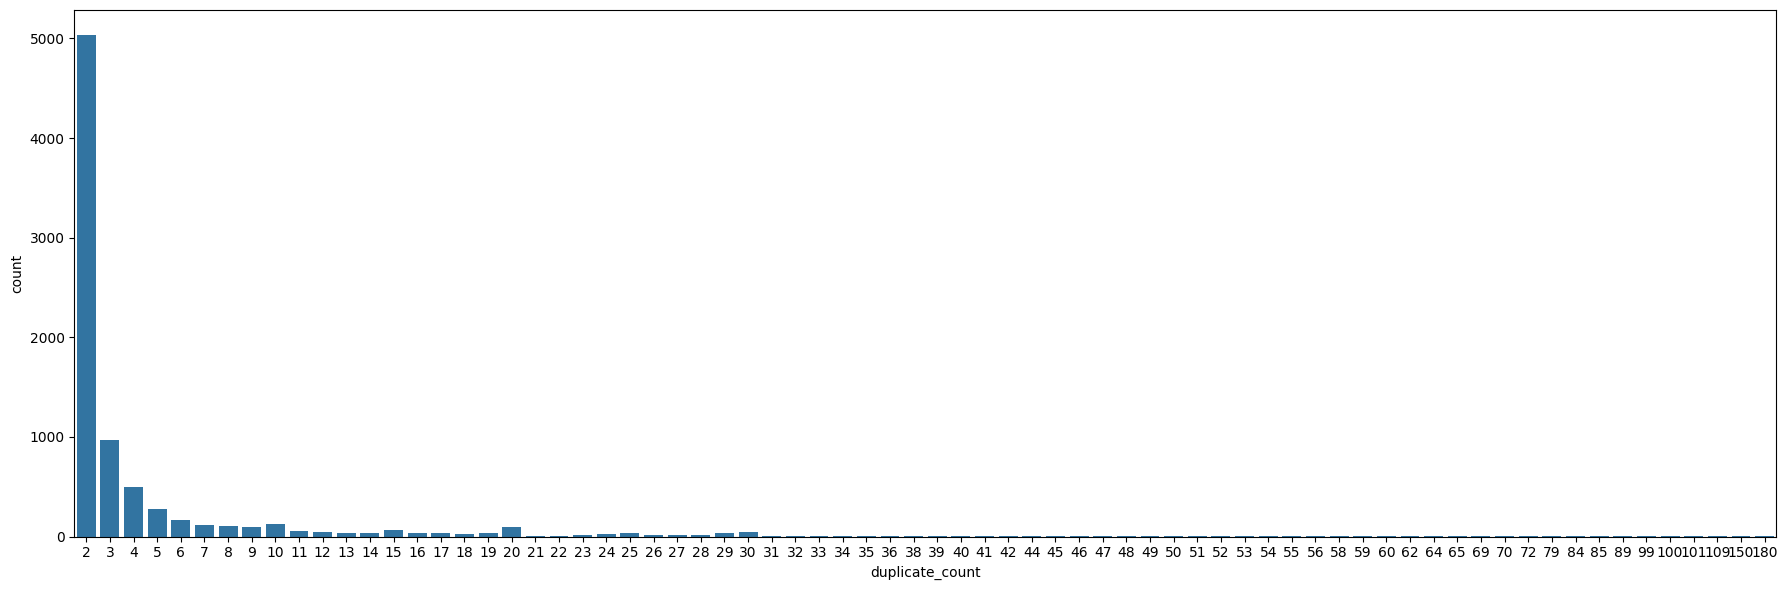

In [31]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.countplot(data=duplicates,
            x="duplicate_count",
            ax=ax)
plt.tight_layout()
plt.show()

* I believe we are dealing with a mix of genuine duplicates and erroneous duplicates.
* Erroneous duplicates could be user input error or database batching error, or a mix of both. 

**1.5 Combine cluster and index delta to identify large adjacent clusters**

In [32]:
def adjacent_clusters(cluster_index):
    idx = pd.Series(sorted(cluster_index))

    breaks = (idx.diff() != 1).cumsum()
    return idx.groupby(breaks).size()

cluster_sizes = (duplicate_df
                 .groupby(cols, dropna=False)
                 .apply(lambda x: adjacent_clusters(x.index), include_groups=False)
                 .reset_index(name="cluster_size"))
cluster_sizes

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,level_32,cluster_size
0,City Hotel,0,0,2023,August,32,7,0,2,2,...,NaN,0,Transient,75.0,0,1,Check-Out,2023-08-09,1,1
1,City Hotel,0,0,2023,August,32,7,0,2,2,...,NaN,0,Transient,75.0,0,1,Check-Out,2023-08-09,2,1
2,City Hotel,0,0,2023,August,32,8,0,1,2,...,NaN,0,Transient,89.0,0,1,Check-Out,2023-08-09,1,1
3,City Hotel,0,0,2023,August,32,8,0,1,2,...,NaN,0,Transient,89.0,0,1,Check-Out,2023-08-09,2,1
4,City Hotel,0,0,2023,August,33,10,1,0,2,...,NaN,0,Transient,75.0,0,0,Check-Out,2023-08-11,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20719,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,NaN,0,Transient-Party,67.0,0,0,Canceled,2024-03-04,4,3
20720,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,NaN,0,Transient-Party,67.0,0,0,Canceled,2023-07-30,1,18
20721,Resort Hotel,1,471,2025,May,20,20,2,5,2,...,NaN,0,Transient,47.0,0,0,Canceled,2025-05-03,1,1
20722,Resort Hotel,1,471,2025,May,20,20,2,5,2,...,NaN,0,Transient,47.0,0,0,Canceled,2025-05-03,2,2


In [ ]:
cluster_sizes["cluster_size"].min(), cluster_sizes["cluster_size"].max(), cluster_sizes["cluster_size"].mean()

(np.int64(1), np.int64(150), np.float64(1.938091102103841))

* 150 adjacent identical rows is another significant finding. 

In [33]:
cluster_sizes.sort_values("cluster_size", ascending=False)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,level_32,cluster_size
10642,City Hotel,1,68,2024,February,8,17,0,2,2,...,NaN,0,Transient,75.0,0,0,Canceled,2024-01-06,1,150
9735,City Hotel,1,34,2023,December,50,8,0,2,1,...,NaN,0,Transient,90.0,0,0,Canceled,2023-11-17,1,100
15112,City Hotel,1,342,2023,September,39,24,2,4,2,...,NaN,0,Transient,170.0,0,0,Canceled,2023-08-21,1,72
14750,City Hotel,1,301,2023,August,33,14,0,2,2,...,NaN,0,Transient-Party,101.5,0,0,Canceled,2023-07-06,1,70
11456,City Hotel,1,99,2024,February,8,19,0,1,2,...,67.0,0,Transient-Party,80.0,0,0,Canceled,2023-12-22,1,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7104,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,17,1
7105,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,18,1
7106,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,19,1
7107,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,20,1


* Upon inspection, the large clusters (150, 100) appear to be paid in full via an agent.
* There is no evidence that the duplicate data is the result of export error. 

**1.6 Non-refund duplicates**

As discovered in the [cancellation EDA](/jupyter_notebooks/02_cancellation_eda.ipynb) notebook, the overwhelming majority of Non Refund bookings are duplicates.

In [ ]:
duplicate_df["deposit_type"].value_counts()



deposit_type
No Deposit    25773
Non Refund    14316
Refundable       76
Name: count, dtype: int64

In [ ]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [ ]:
df["deposit_type"].value_counts() - duplicate_df["deposit_type"].value_counts()

deposit_type
No Deposit    78868
Non Refund      271
Refundable       86
Name: count, dtype: int64

This seems to make a compelling argument for an error, however, we must assume that the hotels' accounts departments would have flagged the errors had the declared payments been missing.

* To fully address this, compare the deposit type to the market segments

In [34]:
deposit_segment = pd.crosstab(duplicate_df["deposit_type"], duplicate_df["market_segment"], normalize="index")
deposit_segment.style.bar(color="darkgreen").format("{:.1%}")

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA
deposit_type,,,,,,,
No Deposit,0.1%,0.3%,4.6%,5.4%,29.6%,28.2%,31.9%
Non Refund,0.0%,0.0%,2.0%,0.1%,63.1%,34.6%,0.3%
Refundable,0.0%,0.0%,2.6%,0.0%,88.2%,0.0%,9.2%


* Here we see 63% of the duplicate non-refundable bookings are in the groups segment and 34.6% in the offline travel agent/tour operator segment both of which regularly book multiple rooms.

## Q1 Conclusions

* The data supports the assumption that group bookings account for the majority of duplicated bookings - 63%
* The remaining 14704 duplicates (12% of total bookings) can be plausibly explained by normal hotel booking behaviour
* Without booking reference or guest ID fields, there is no way to conclusively separate coincidental collisions from export artifacts. The groups and travel agent/tour operator findings account for the substantial majority of duplicates 
* There is nothing in the remaining pattern (cluster sizes, distribution across the file) to suggest systematic duplication rather than normal booking behaviour.
* Staff user error cannot be ruled out, but would be expected to persist

**Revenue Manager's Decision:**

The duplicates are genuine and should remain in place throughout.

---